
# Кейс спринта


Заказчик проекта — «Карта ДТП». Это некоммерческий проект, посвящённый проблеме дорожно-транспортных происшествий в России. Цель проекта — повысить безопасность на дорогах.

«Карта ДТП» помогает выявлять реальные причины ДТП, оценивать уровень развития инфраструктуры, а также разрабатывать качественные решения и программы по повышению безопасности на улицах и дорогах. Заказчик хочет собирать данные более высокого качества и ожидает от вас рекомендаций: на какие проблемы или особенности обратить внимание.

## Что нужно сделать

Вам необходимо проверить, встречаются ли в данных дубликаты и пропуски. Это поможет заказчикам собирать более качественные данные.

Вам также понадобится ответить на следующие вопросы:

- как менялось число ДТП по временным промежуткам;

- различается ли число ДТП для групп водителей с разным стажем.


## Описание данных

Данные `Kirovskaya_oblast.csv`, `Moscowskaya_oblast.csv` содержат информацию ДТП:

* `geometry.coordinates` — координаты ДТП;

* `id` — идентификатор ДТП;

*  `properties.tags` — тег происшествия;

*  `properties.light` — освещённость;

*  `properties.point.lat` — широта;

*  `properties.point.long` — долгота;

*  `properties.nearby` — ближайшие объекты;

*  `properties.region` — регион;

*  `properties.scheme` — схема ДТП;

*  `properties.address` — ближайший адрес;

*  `properties.weather` — погода;

*  `properties.category` — категория ДТП;

*  `properties.datetime` — дата и время ДТП;

*  `properties.injured_count` — число пострадавших;

*  `properties.parent_region` — область;

*  `properties.road_conditions` — состояние покрытия;

*  `properties.participants_count` — число участников;

*  `properties.participant_categories` — категории участников.

`Moscowskaya_oblast_participiants.csv`, `Kirovskaya_oblast_participiants.csv` — сведения об участниках ДТП:

* `role` — роль;

* `gender` — пол;

* `violations` — какие правила дорожного движения были нарушены конкретным участником;

* `health_status` — состояние здоровья после  ДТП;

* `years_of_driving_experience` — число лет опыта;

* `id` — идентификатор ДТП.


`Kirovskaya_oblast_vehicles.csv`, `Moscowskaya_oblast_vehicles.csv` — сведения о транспортных средствах:

* `year` — год выпуска;

* `brand` — марка транспортного средства;

* `color` — цвет;

* `model` — модель;

* `category` — категория;

* `id` — идентификатор ДТП.

<a class="anchor" id="3-bullet"></a>
## Содержимое проекта

- [3. Содержимое проекта](#3-bullet)
- [4. Загрузка данных и знакомство с ними](#4-bullet)
- [5. Проверка ошибок и предобработка](#5-bullet)
    - [5.1 Названия столбцов](#5.1-bullet)
    - [5.2 Пропуски в данных](#5.2-bullet)
    - [5.3 Дубликаты](#5.3-bullet)
    - [5.4 Типы данных](#5.4-bullet)
- [6. Исследовательский анализ](#6-bullet)
    - [6.1 Распределение ДТП по времени](#6.1-bullet)
    - [6.2 ДТП и стаж водителей](#6.2-bullet)
    - [6.3 Сравнение Кировской и Московской областей](#6.3-bullet)
- [7. Итоговые выводы и рекомендации](#7-bullet)

<a class="anchor" id="4-bullet"></a>
## Загрузка данных и знакомство с ними

Загрузим сначала все датасеты.

In [1]:
import pandas as pd
import datetime as dt

Установили библиотеку 

In [2]:
%pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [3]:
import missingno as msno

In [4]:
kirov = pd.read_csv('https://code.s3.yandex.net/datasets/Kirovskaya_oblast.csv')
moscow = pd.read_csv('https://code.s3.yandex.net/datasets/Moscowskaya_oblast.csv')

kirov_part = pd.read_csv('https://code.s3.yandex.net/datasets/Kirovskaya_oblast_participiants.csv')
moscow_part = pd.read_csv('https://code.s3.yandex.net/datasets/Moscowskaya_oblast_participiants.csv')

kirov_veh = pd.read_csv('https://code.s3.yandex.net/datasets/Kirovskaya_oblast_vehicles.csv')
moscow_veh = pd.read_csv('https://code.s3.yandex.net/datasets/Moscowskaya_oblast_vehicles.csv')


Выведем по всем датасетам количсевто строк и столбцов.

In [5]:
for df in [kirov, moscow, kirov_part, moscow_part, kirov_veh, moscow_veh]:
    display(df.shape)

(14517, 18)

(45618, 18)

(31235, 6)

(95177, 6)

(20093, 6)

(65606, 6)

Изучим Кировскую область.

In [6]:
kirov.info()
kirov.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14517 entries, 0 to 14516
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   geometry.coordinates               14517 non-null  object 
 1   id                                 14517 non-null  int64  
 2   properties.tags                    14517 non-null  object 
 3   properties.light                   14517 non-null  object 
 4   properties.point.lat               14485 non-null  float64
 5   properties.point.long              14485 non-null  float64
 6   properties.nearby                  14517 non-null  object 
 7   properties.region                  14517 non-null  object 
 8   properties.scheme                  13380 non-null  float64
 9   properties.address                 13843 non-null  object 
 10  properties.weather                 14517 non-null  object 
 11  properties.category                14517 non-null  obj

,geometry.coordinates,id,properties.tags,properties.light,properties.point.lat,properties.point.long,properties.nearby,properties.region,properties.scheme,properties.address,properties.weather,properties.category,properties.datetime,properties.injured_count,properties.parent_region,properties.road_conditions,properties.participants_count,properties.participant_categories
0,"[47.875603, 57.24379]",1983180,Дорожно-транспортные происшествия,Светлое время суток,57.243790,47.875603,[],Яранский район,600.0,Р-176 Вятка Чебоксары - Йошкар-Ола - Киров - С...,['Дождь'],Опрокидывание,2017-07-01 18:00:00,1,Кировская область,['Мокрое'],3,['Все участники']
1,"[47.87903, 57.304807]",2889433,Дорожно-транспортные происшествия,Светлое время суток,57.304807,47.879030,"['Административные здания', 'Нерегулируемый пе...",Яранский район,710.0,"г Яранск, ул Кирова, 10",['Ясно'],Наезд на пешехода,2023-09-12 17:10:00,1,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",2,"['Все участники', 'Пешеходы']"
2,"[47.840781, 57.297156]",2591208,Дорожно-транспортные происшествия,Сумерки,57.297156,47.840781,"['Жилые дома индивидуальной застройки', 'Нерег...",Яранский район,NaN,"г Яранск, ул Чапаева, 80",['Пасмурно'],Съезд с дороги,2021-07-02 21:25:00,1,Кировская область,['Мокрое'],1,['Все участники']
3,"[47.834365, 57.244775]",2577639,Дорожно-транспортные происшествия,Светлое время суток,57.244775,47.834365,['Жилые дома индивидуальной застройки'],Яранский район,200.0,"м Знаменка, ул Кирова, 15",['Пасмурно'],Столкновение,2021-05-31 18:55:00,1,Кировская область,['Сухое'],2,"['Все участники', 'Мотоциклисты']"
4,"[47.968197, 57.357738]",1981026,Дорожно-транспортные происшествия,Светлое время суток,57.357738,47.968197,['Нерегулируемый перекрёсток неравнозначных ул...,Яранский район,NaN,"с/п Никольское, Киров-Советск- Яранск - подъез...",['Ясно'],Опрокидывание,2018-05-16 16:25:00,2,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",2,['Все участники']


In [7]:
kirov.sample(3, random_state=42)

,geometry.coordinates,id,properties.tags,properties.light,properties.point.lat,properties.point.long,properties.nearby,properties.region,properties.scheme,properties.address,properties.weather,properties.category,properties.datetime,properties.injured_count,properties.parent_region,properties.road_conditions,properties.participants_count,properties.participant_categories
11765,"[49.326532, 58.956338]",1988622,Дорожно-транспортные происшествия,Светлое время суток,58.956338,49.326532,[],Юрьянский район,10.0,Р-176 Вятка Чебоксары - Йошкар-Ола - Киров - С...,"['Снегопад', 'Метель']",Столкновение,2019-02-05 15:10:00,1,Кировская область,['Обработанное противогололедными материалами'],4,['Все участники']
836,"[48.928986, 57.595765]",2591843,Дорожно-транспортные происшествия,"В темное время суток, освещение отсутствует",57.595765,48.928986,"['Мост', 'Остановка общественного транспорта',...",Советский район,820.0,"г Советск, Киров - Советск - Яранск, 133 км",['Дождь'],Наезд на пешехода,2021-07-04 01:34:00,1,Кировская область,['Мокрое'],2,"['Все участники', 'Пешеходы']"
1475,"[49.254037, 58.469716]",3011739,Дорожно-транспортные происшествия,Светлое время суток,58.469716,49.254037,['Нерегулируемый перекрёсток неравнозначных ул...,Оричевский район,210.0,"тер Стрижевское городское поселение, ул Кирова...",['Ясно'],Столкновение,2024-08-26 15:55:00,2,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",3,"['Все участники', 'Мотоциклисты']"


In [8]:
kirov_part.info()
kirov_part.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31235 entries, 0 to 31234
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   role                         31235 non-null  object 
 1   gender                       30387 non-null  object 
 2   violations                   31235 non-null  object 
 3   health_status                31135 non-null  object 
 4   years_of_driving_experience  16909 non-null  float64
 5   id                           31235 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 1.4+ MB


,role,gender,violations,health_status,years_of_driving_experience,id
0,Водитель,Мужской,['Несоответствие скорости конкретным условиям ...,"Раненый, находящийся (находившийся) на амбулат...",26.0,1983180
1,Водитель,Мужской,[],Не пострадал,34.0,2889433
2,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208
3,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208
4,Водитель,Мужской,[],Не пострадал,27.0,2577639


In [9]:
kirov_veh.info()
kirov_veh.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20093 entries, 0 to 20092
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      19299 non-null  float64
 1   brand     19318 non-null  object 
 2   color     19643 non-null  object 
 3   model     19318 non-null  object 
 4   category  20093 non-null  object 
 5   id        20093 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 942.0+ KB


,year,brand,color,model,category,id
0,2011.0,ВАЗ,Серый,Kalina,"А-класс (особо малый) до 3,5 м",1983180
1,2005.0,CHEVROLET,Зеленый,Niva,"С-класс (малый средний, компактный) до 4,3 м",2889433
2,2017.0,RENAULT,Синий,Logan,"С-класс (малый средний, компактный) до 4,3 м",2591208
3,2006.0,ВАЗ,Зеленый,ВАЗ 2115 и модификации,"С-класс (малый средний, компактный) до 4,3 м",2577639
4,1986.0,MERCEDES,Зеленый,Прочие модели Mercedes,Фургоны,1981026


Изучим Московскую область.

In [10]:
moscow.info()
moscow.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45618 entries, 0 to 45617
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   geometry.coordinates               45618 non-null  object 
 1   id                                 45618 non-null  int64  
 2   properties.tags                    45618 non-null  object 
 3   properties.light                   45618 non-null  object 
 4   properties.point.lat               45615 non-null  float64
 5   properties.point.long              45615 non-null  float64
 6   properties.nearby                  45618 non-null  object 
 7   properties.region                  45618 non-null  object 
 8   properties.scheme                  44235 non-null  float64
 9   properties.address                 43862 non-null  object 
 10  properties.weather                 45618 non-null  object 
 11  properties.category                45618 non-null  obj

,geometry.coordinates,id,properties.tags,properties.light,properties.point.lat,properties.point.long,properties.nearby,properties.region,properties.scheme,properties.address,properties.weather,properties.category,properties.datetime,properties.injured_count,properties.parent_region,properties.road_conditions,properties.participants_count,properties.participant_categories
0,"[37.5253, 55.9992]",2163589,['Дорожно-транспортные происшествия'],Светлое время суток,55.999200,37.525300,"['Мост, эстакада, путепровод', 'Крупный торгов...",Мытищинский,NaN,"ХЛЕБНИКОВО-РОГАЧЕВО, 0 км",['Ясно'],Столкновение,2019-01-31 09:05:00,1,Московская область,"['Мокрое', 'Отсутствие, плохая различимость го...",3,['Все участники']
1,"[37.058966, 55.788688]",2155398,"['Дорожно-транспортные происшествия', 'ДТП и п...","В темное время суток, освещение включено",55.788688,37.058966,[],Истринский,70.0,М-9 Балтия Москва - Волоколамск - граница с Ла...,['Ясно'],Столкновение,2018-09-22 05:00:00,2,Московская область,['Сухое'],4,"['Все участники', 'Дети']"
2,"[37.4419, 56.0081]",2163319,['Дорожно-транспортные происшествия'],"В темное время суток, освещение включено",56.008100,37.441900,"['Многоквартирные жилые дома', 'Остановка обще...",Лобня,820.0,"г Лобня, ул Ленина, 43",['Пасмурно'],Наезд на пешехода,2019-01-24 19:30:00,1,Московская область,['Обработанное противогололедными материалами'],2,"['Все участники', 'Пешеходы']"
3,"[38.6614, 55.4358]",2143938,['Дорожно-транспортные происшествия'],Светлое время суток,55.435800,38.661400,['Регулируемый перекресток'],Воскресенский,300.0,ЖУКОВСКИЙ-РАМЕНСКОЕ-СТ.БРОННИЦЫ-ЧЕЧЕВИЛОВО-МБК...,['Ясно'],Столкновение,2018-01-25 16:00:00,2,Московская область,['Обработанное противогололедными материалами'...,3,['Все участники']
4,"[38.29207, 55.50502]",2163390,['Дорожно-транспортные происшествия'],"В темное время суток, освещение отсутствует",55.505020,38.292070,['Нерегулируемый перекрёсток неравнозначных ул...,Раменский,500.0,"ММК-РАМЕНСКОЕ, 4 км",['Ясно'],Столкновение,2019-01-14 17:40:00,1,Московская область,['Обработанное противогололедными материалами'],2,['Все участники']


In [11]:
moscow_part.info()
moscow_part.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95177 entries, 0 to 95176
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   role                         95177 non-null  object 
 1   gender                       93307 non-null  object 
 2   violations                   95177 non-null  object 
 3   health_status                95070 non-null  object 
 4   years_of_driving_experience  59679 non-null  float64
 5   id                           95177 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 4.4+ MB


,role,gender,violations,health_status,years_of_driving_experience,id
0,Водитель,Мужской,[],Не пострадал,13.0,2163589
1,Водитель,Мужской,[],Не пострадал,13.0,2163589
2,Водитель,Мужской,['Неправильный выбор дистанции'],Не пострадал,5.0,2155398
3,Водитель,Мужской,['Неправильный выбор дистанции'],Не пострадал,5.0,2155398
4,Водитель,Женский,[],Не пострадал,11.0,2163319


In [12]:
moscow_veh.info()
moscow_veh.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65606 entries, 0 to 65605
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      63860 non-null  float64
 1   brand     64185 non-null  object 
 2   color     64765 non-null  object 
 3   model     64185 non-null  object 
 4   category  65606 non-null  object 
 5   id        65606 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 3.0+ MB


,year,brand,color,model,category,id
0,2012.0,ГАЗ,Белый,Прочие модели ГАЗ,Фургоны,2163589
1,2008.0,OPEL,Черный,Astra,"С-класс (малый средний, компактный) до 4,3 м",2155398
2,2017.0,MAZDA,Черный,CX-5,"В-класс (малый) до 3,9 м",2163319
3,2013.0,ГАЗ,Белый,"2705 Газель , 27057 и модификации",Фургоны,2143938
4,2011.0,RENAULT,Синий,Прочие модели Renault,"В-класс (малый) до 3,9 м",2163390


[Назад к содержанию](#3-bullet)

<a class="anchor" id="5-bullet"></a>
## Проверка ошибок в данных и их предобработка



<a class="anchor" id="5.1-bullet"></a>
### Замена названий (меток) столбцов на оптимальные для работы

Смотрим на заголовки.

In [13]:
dfs = {
    'kirov': kirov,
    'moscow': moscow,
    'kirov_part': kirov_part,
    'moscow_part': moscow_part,
    'kirov_veh': kirov_veh,
    'moscow_veh': moscow_veh
}

for name, df in dfs.items():
    print(f'Колонки в {name}:')
    display(pd.DataFrame(df.columns, columns=['column_name']))

Колонки в kirov:


,column_name
0,geometry.coordinates
1,id
2,properties.tags
3,properties.light
4,properties.point.lat
5,properties.point.long
6,properties.nearby
7,properties.region
8,properties.scheme
9,properties.address


Колонки в moscow:


,column_name
0,geometry.coordinates
1,id
2,properties.tags
3,properties.light
4,properties.point.lat
5,properties.point.long
6,properties.nearby
7,properties.region
8,properties.scheme
9,properties.address


Колонки в kirov_part:


...

,column_name
0,role
1,gender
2,violations
3,health_status
4,years_of_driving_experience
5,id


Колонки в kirov_veh:


,column_name
0,year
1,brand
2,color
3,model
4,category
5,id


Колонки в moscow_veh:


,column_name
0,year
1,brand
2,color
3,model
4,category
5,id


Заменили названия колонок.

In [14]:
accident_cols = {
    'geometry.coordinates': 'coordinates',
    'properties.tags': 'tags',
    'properties.light': 'light',
    'properties.point.lat': 'lat',
    'properties.point.long': 'lon',
    'properties.nearby': 'nearby_objects',
    'properties.region': 'region',
    'properties.scheme': 'scheme',
    'properties.address': 'address',
    'properties.weather': 'weather',
    'properties.category': 'accident_category',
    'properties.datetime': 'datetime',
    'properties.injured_count': 'injured_count',
    'properties.parent_region': 'parent_region',
    'properties.road_conditions': 'road_conditions',
    'properties.participants_count': 'participants_count',
    'properties.participant_categories': 'participant_categories'
}

participants_cols = {
    'years_of_driving_experience': 'driving_experience_years'
}

vehicles_cols = {
    'year': 'vehicle_year',
    'category': 'vehicle_category'
}

kirov = kirov.rename(columns=accident_cols)
moscow = moscow.rename(columns=accident_cols)

kirov_part = kirov_part.rename(columns=participants_cols)
moscow_part = moscow_part.rename(columns=participants_cols)

kirov_veh = kirov_veh.rename(columns=vehicles_cols)
moscow_veh = moscow_veh.rename(columns=vehicles_cols)

In [15]:
dfs = {
    'kirov': kirov,
    'moscow': moscow,
    'kirov_part': kirov_part,
    'moscow_part': moscow_part,
    'kirov_veh': kirov_veh,
    'moscow_veh': moscow_veh
}

for name, df in dfs.items():
    print(f'Колонки в {name}:')
    display(pd.DataFrame(df.columns, columns=['column_name']))

Колонки в kirov:


,column_name
0,coordinates
1,id
2,tags
3,light
4,lat
5,lon
6,nearby_objects
7,region
8,scheme
9,address


Колонки в moscow:


,column_name
0,coordinates
1,id
2,tags
3,light
4,lat
5,lon
6,nearby_objects
7,region
8,scheme
9,address


Колонки в kirov_part:


...

,column_name
0,role
1,gender
2,violations
3,health_status
4,driving_experience_years
5,id


Колонки в kirov_veh:


,column_name
0,vehicle_year
1,brand
2,color
3,model
4,vehicle_category
5,id


Колонки в moscow_veh:


,column_name
0,vehicle_year
1,brand
2,color
3,model
4,vehicle_category
5,id


[Назад к содержанию](#3-bullet)

<a class="anchor" id="5.2-bullet"></a>
### Проверка пропусков в данных

На примере датасета `Kirovskaya_oblast.csv` изучите, в каких столбцах есть пропуски. Предположите причины их возникновения. Напишите рекомендации, как работать с  пропусками и как их в дальнейшем избежать.

Ищем пропуски.

In [16]:
# посмотрим, где есть пропуски
kirov.isna().sum()

coordinates                  0
id                           0
tags                         0
light                        0
lat                         32
lon                         32
nearby_objects               0
region                       0
scheme                    1137
address                    674
weather                      0
accident_category            0
datetime                     0
injured_count                0
parent_region                0
road_conditions              0
participants_count           0
participant_categories       0
dtype: int64

In [17]:
kirov.isna().mean().round(3) * 100 # доля пропусков

coordinates               0.0
id                        0.0
tags                      0.0
light                     0.0
lat                       0.2
lon                       0.2
nearby_objects            0.0
region                    0.0
scheme                    7.8
address                   4.6
weather                   0.0
accident_category         0.0
datetime                  0.0
injured_count             0.0
parent_region             0.0
road_conditions           0.0
participants_count        0.0
participant_categories    0.0
dtype: float64

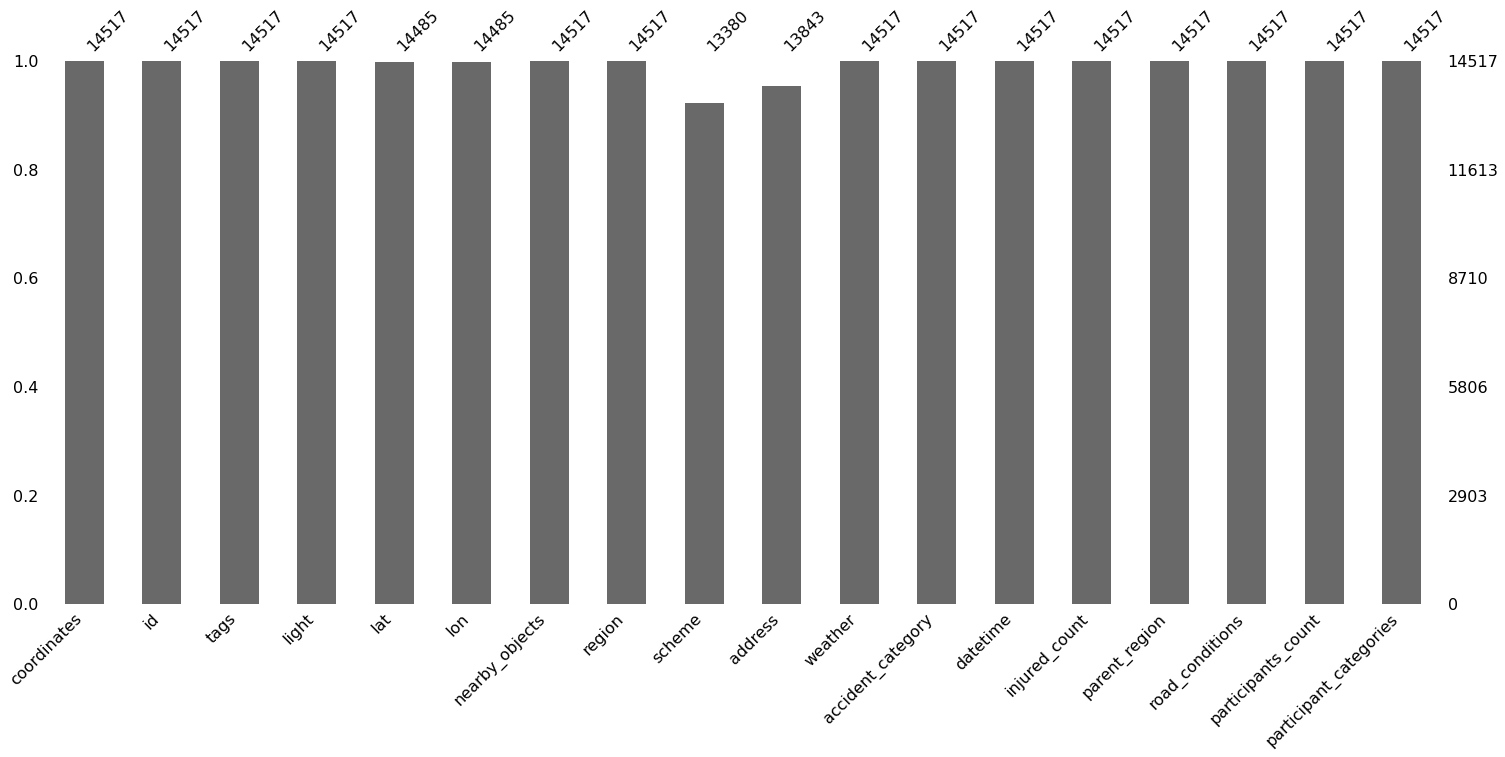

In [18]:
import matplotlib.pyplot as plt

msno.bar(kirov)
plt.show() 

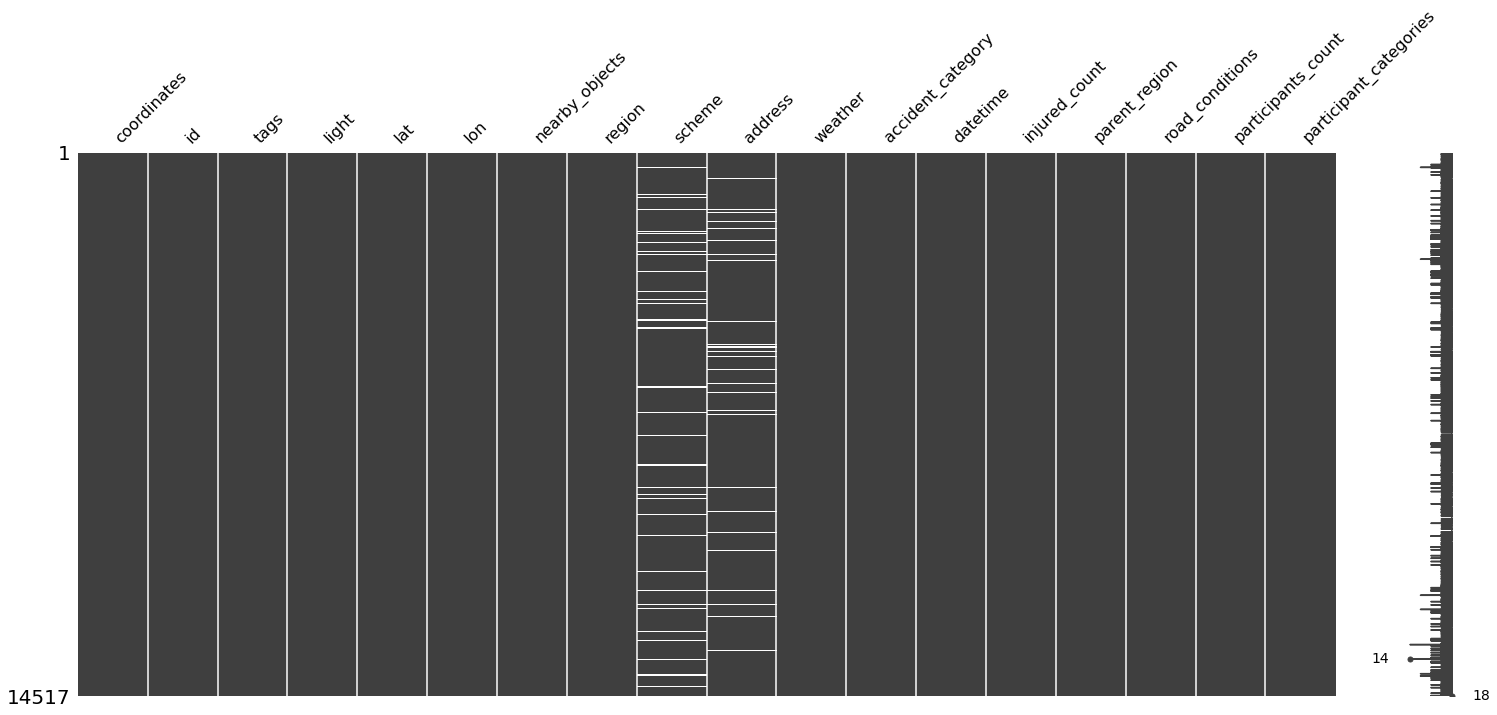

In [19]:
msno.matrix(kirov)
plt.show()

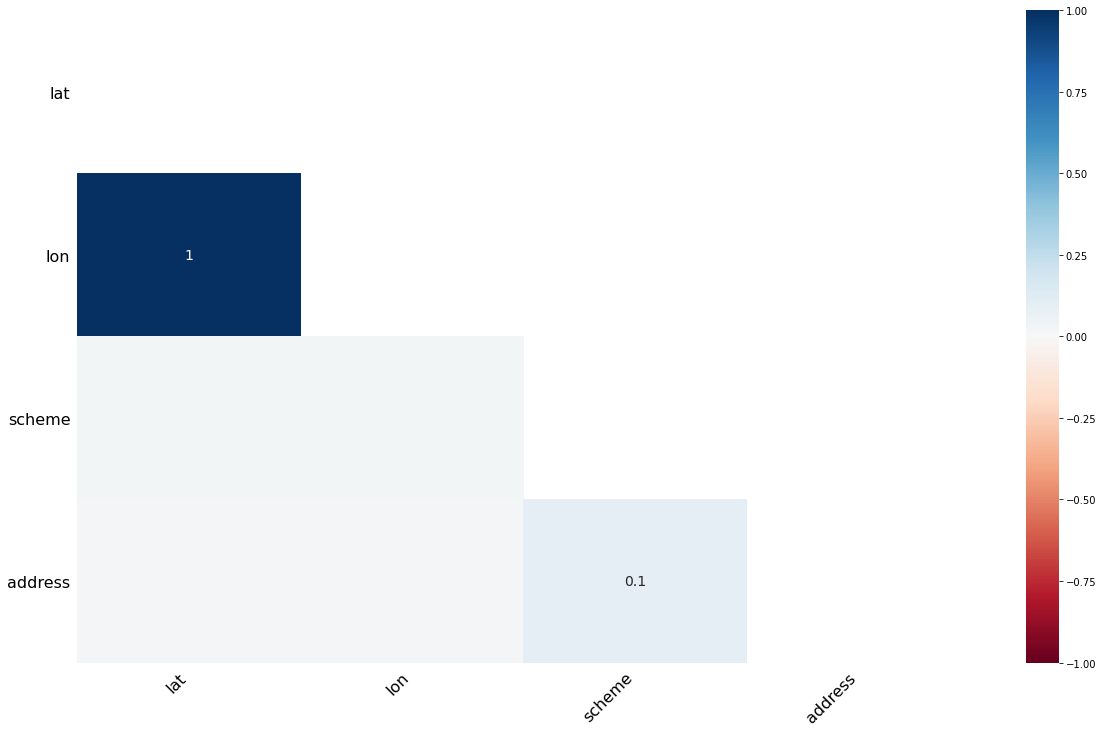

In [20]:
msno.heatmap(kirov)
plt.show()

**Результат поиска пропусков**

- В датасете `kirov` пропуски есть в трёх столбцах: `lat` и `lon` (по 0.2% строк) и `scheme` (7.8% строк), а также в `address` (4.6% строк).
- Остальные поля заполнены полностью, поэтому их можно использовать без дополнительной обработки пропусков.

**Предполагаемые причины пропусков**

- Для части ДТП не удалось корректно зафиксировать координаты (`lat`, `lon`), не была составлена или выгружена схема (`scheme`), а также не всегда удалось определить или сохранить точный адрес (`address`).
- Это может быть связано с техническими сбоями (GPS, геокодер), особенностями заполнения карточек ДТП и необязательностью этих полей для ответственных сотрудников.

**Рекомендации по работе с пропусками**

- Для анализа географии ДТП (карты, расстояния, кластеризация) буду использовать только строки с заполненными `lat` и `lon`, без подстановки вымышленных координат.  
- В задачах, где критичны `scheme` и `address`, буду либо отфильтровывать строки с пропусками, либо выделять отдельную категорию «нет схемы/адреса» и анализировать её отдельно.  
- В агрегированных показателях (по датам, районам, категориям ДТП) допускается использовать события с пропусками в `scheme`/`address`, если эти поля не влияют на расчёт, но важно учитывать, что часть карточек неполная.

**Рекомендации по снижению числа пропусков**

- Сделать координаты (`lat`, `lon`) и адрес (`address`) обязательными полями в системе регистрации ДТП и улучшить автоматическое определение адреса по координатам.  
- Для поля `scheme` ввести обязательное заполнение хотя бы для серьёзных ДТП и добавить проверки интерфейса, которые не позволят сохранить карточку без схемы и ключевых атрибутов (координаты/адрес, категория ДТП, число пострадавших).

In [21]:
# 1. Не трогаем координаты: используем только полные строки при гео-анализе
kirov_geo = kirov.dropna(subset=['lat', 'lon'])

# 2. Обработка scheme:
#    - отдельно сохраним флаг "нет схемы"
kirov['has_scheme'] = kirov['scheme'].notna()

# 3. Обработка address:
#    - заведём категорию 'нет адреса' (например, для сводных таблиц)
kirov['address_filled'] = kirov['address'].notna()

# 4. Если очень нужно временно заполнить пропуски в адресе текстом:
kirov['address_filled_text'] = kirov['address'].fillna('нет адреса')

# 5. Проверим, что пропуски остались только там, где это допустимо
kirov.isna().mean().round(3) * 100


coordinates               0.0
id                        0.0
tags                      0.0
light                     0.0
lat                       0.2
lon                       0.2
nearby_objects            0.0
region                    0.0
scheme                    7.8
address                   4.6
weather                   0.0
accident_category         0.0
datetime                  0.0
injured_count             0.0
parent_region             0.0
road_conditions           0.0
participants_count        0.0
participant_categories    0.0
has_scheme                0.0
address_filled            0.0
address_filled_text       0.0
dtype: float64

**После обработки пропусков**

- Пропуски остались только в координатах `lat` и `lon` (по 0.2% строк), их не заполнял, чтобы не искажать геоданные.
- Поле `scheme` с 7.8% пропусков и `address` с 4.6% пропусков не заполнял искусственно. Вместо этого добавлены вспомогательные признаки:
  - `has_scheme` — флаг, заполнена ли схема ДТП;
  - `address_filled` — флаг, есть ли адрес;
  - `address_filled_text` — текстовый вариант адреса, где пропуски заменены на категорию `нет адреса`.
- Остальные поля не содержат пропусков и могут использоваться в анализе без дополнительной обработки.

**Такой подход позволяет**
- использовать только строки с полными координатами для геоаналитики (карты, расстояния, кластеризация);
- учитывать записи без схемы/адреса через отдельные флаги и категорию `нет адреса`, не подменяя реальные данные.


[Назад к содержанию](#3-bullet)

<a class="anchor" id="5.3-bullet"></a>
### Наличие явных и неявных дубликатов в данных



**Явные дубликаты**

Посчитали только у Кировской области в 1 датасете.

In [22]:
# считаем число полностью совпадающих строк (явных дубликатов)
dup_count = kirov.duplicated().sum()

# считаем общее число строк в датафрейме
total = len(kirov)

# доля дубликатов в процентах
dup_percent = dup_count / total * 100

dup_count, round(dup_percent, 2)

(0, 0.0)

Посчитали среди всех датасетов.

In [23]:
# dfs ранее определили как словарь датафреймов
for name, df in dfs.items():
    # считаем число полностью совпадающих строк (явных дубликатов)
    dup_count = df.duplicated().sum()
    
    # считаем общее число строк
    total = len(df)
    
    # доля дубликатов в процентах
    dup_percent = dup_count / total * 100
    
    display(
        f'В данных {name} найдено {dup_count} явных дубликатов, '
        f'что составляет {round(dup_percent, 1)}% от всех строк.'
    )


'В данных kirov найдено 0 явных дубликатов, что составляет 0.0% от всех строк.'

'В данных moscow найдено 0 явных дубликатов, что составляет 0.0% от всех строк.'

'В данных kirov_part найдено 9727 явных дубликатов, что составляет 31.1% от всех строк.'

'В данных moscow_part найдено 35428 явных дубликатов, что составляет 37.2% от всех строк.'

'В данных kirov_veh найдено 18 явных дубликатов, что составляет 0.1% от всех строк.'

'В данных moscow_veh найдено 706 явных дубликатов, что составляет 1.1% от всех строк.'

- В данных `kirov` и `moscow` явных дубликатов нет (0 строк, 0% от всех строк).
- В данных `kirov_part` найдено 9727 явных дубликатов (31.1% строк), в `moscow_part` — 35428 дубликатов (37.2% строк).
- В данных `kirov_veh` найдено 18 дубликатов (0.1% строк), в `moscow_veh` — 706 дубликатов (1.1% строк).

**Что сделано**

- Во всех таблицах с участниками (`kirov_part`, `moscow_part`) и транспортными средствами (`kirov_veh`, `moscow_veh`) явные дубликаты удалены методом `drop_duplicates()`.
- Это позволяет избежать искусственного завышения числа участников ДТП и транспортных средств при дальнейшем анализе.


In [24]:
# удалим явные дубликаты в таблицах участников и ТС,
# чтобы не завышать число участников/машин
kirov_part = kirov_part.drop_duplicates().reset_index(drop=True)
moscow_part = moscow_part.drop_duplicates().reset_index(drop=True)
kirov_veh = kirov_veh.drop_duplicates().reset_index(drop=True)
moscow_veh = moscow_veh.drop_duplicates().reset_index(drop=True)

# проверим размеры после удаления дубликатов
clean_shapes = {
    'kirov_part_clean': kirov_part.shape,
    'moscow_part_clean': moscow_part.shape,
    'kirov_veh_clean': kirov_veh.shape,
    'moscow_veh_clean': moscow_veh.shape
}
clean_shapes

{'kirov_part_clean': (21508, 6),
 'moscow_part_clean': (59749, 6),
 'kirov_veh_clean': (20075, 6),
 'moscow_veh_clean': (64900, 6)}

**После удаления явных дубликатов**

- В таблицах участников осталось 21508 строк для Кировской области и 59749 строк для Московской области (`kirov_part`, `moscow_part`), по 6 столбцов в каждой.
- В таблицах транспортных средств осталось 20075 строк для Кировской области и 64900 строк для Московской области (`kirov_veh`, `moscow_veh`), также по 6 столбцов.
- Размеры соответствуют ожидаемому сокращению на число дубликатов: данные по участникам и ТС очищены от полностью повторяющихся записей и готовы к дальнейшему анализу.


**Неявные дубликаты**

In [25]:
# проверяем на неявные дубликаты ДТП на примере kirov

# 1. Ищем ДТП с одинаковыми координатами и временем
#    считаем, есть ли строки, где совпадают lat, lon и datetime
kirov[kirov.duplicated(subset=['lat', 'lon', 'datetime'], keep=False)]

,coordinates,id,tags,light,lat,lon,nearby_objects,region,scheme,address,...,accident_category,datetime,injured_count,parent_region,road_conditions,participants_count,participant_categories,has_scheme,address_filled,address_filled_text


In [26]:
# 2. Проверяем, что идентификаторы ДТП действительно уникальны
#    сравниваем число уникальных id с общим числом id
kirov['id'].nunique() == kirov['id'].count()

True

In [27]:
moscow[moscow.duplicated(subset=['lat', 'lon', 'datetime'], keep=False)]

,coordinates,id,tags,light,lat,lon,nearby_objects,region,scheme,address,weather,accident_category,datetime,injured_count,parent_region,road_conditions,participants_count,participant_categories


In [28]:
moscow['id'].nunique() == moscow['id'].count()

True

- Комбинация `lat` + `lon` + `datetime` выглядит достаточно уникальной для события ДТП.  
- В данных `kirov` / `moscow` строки с совпадающими координатами и временем не обнаружены, неявных дубликатов по этой связке нет.  
Число уникальных идентификаторов `id` равно общему числу `id` (`df['id'].nunique() == df['id'].count()` даёт `True`), каждый идентификатор ДТП уникален.


In [29]:
participants = {
    'kirov_part': kirov_part,
    'moscow_part': moscow_part
}

part_key = [
    'id',
    'role', # роль (водитель, пассажир, пешеход)
    'gender',
    'violations', # нарушения ПДД
    'health_status',
    'driving_experience_years'
]

for name, df in participants.items():
    # кандидаты в неявные дубликаты
    dup_mask = df.duplicated(subset=part_key, keep=False)
    dups = df[dup_mask]
    
    display(f'{name}')
    display('Число потенциальных неявных дубликатов по ключу участника:', len(dups))
    display(dups.head())

'kirov_part'

'Число потенциальных неявных дубликатов по ключу участника:'

0

,role,gender,violations,health_status,driving_experience_years,id


'moscow_part'

'Число потенциальных неявных дубликатов по ключу участника:'

0

,role,gender,violations,health_status,driving_experience_years,id


- Для таблиц `kirov_part` и `moscow_part` проверена комбинация полей  
  `id` + `role` + `gender` + `violations` + `health_status` + `driving_experience_years`.
- Строк с полностью совпадающими значениями по этому набору признаков не обнаружено:  
  число потенциальных неявных дубликатов участника в рамках одного ДТП равно 0 для обоих датасетов.
- Это означает, что один и тот же участник не продублирован в данных абсолютно идентичными записями, и таблицы участников можно использовать без дополнительного удаления неявных дублей.

In [30]:
# неявные дубликаты ТС: одна и та же машина в рамках одного ДТП
vehicles = {
    'kirov_veh': kirov_veh,
    'moscow_veh': moscow_veh
}

veh_key = [
    'id',               # ДТП
    'brand',            # марка
    'model',            # модель
    'vehicle_year',     # год выпуска
    'vehicle_category', # категория ТС
    'color'             # цвет
]

for name, df in vehicles.items():
    # маска: True там, где строка входит в группу полных совпадений по veh_key
    # keep=False -> все одинаковые строки помечаются как дубликаты, а не только первая/последняя
    dup_mask = df.duplicated(subset=veh_key, keep=False)
    
    # сами кандидаты в неявные дубликаты ТС
    dups = df[dup_mask]
    
    display(f'{name}')
    display('Число потенциальных неявных дубликатов по ключу ТС:', len(dups))
    display(dups.head())

'kirov_veh'

'Число потенциальных неявных дубликатов по ключу ТС:'

0

,vehicle_year,brand,color,model,vehicle_category,id


'moscow_veh'

'Число потенциальных неявных дубликатов по ключу ТС:'

0

,vehicle_year,brand,color,model,vehicle_category,id


- Для таблиц `kirov_veh` и `moscow_veh` проверена комбинация полей  
  `id` + `brand` + `model` + `vehicle_year` + `vehicle_category` + `color`.
- По этому ключу не найдено ни одной пары полностью совпадающих строк:  
  число потенциальных неявных дубликатов транспортных средств равно 0 для обоих датасетов.
- Это означает, что одна и та же машина в рамках одного ДТП не продублирована в данных идентичными записями, и таблицы `kirov_veh` и `moscow_veh` можно использовать без дополнительного удаления неявных дублей.

[Назад к содержанию](#3-bullet)

<a class="anchor" id="5.4-bullet"></a>
### Проверка корректности типов данных

In [31]:
for name, df in dfs.items():
    display(name)
    display(df.dtypes)

'kirov'

coordinates                object
id                          int64
tags                       object
light                      object
lat                       float64
lon                       float64
nearby_objects             object
region                     object
scheme                    float64
address                    object
weather                    object
accident_category          object
datetime                   object
injured_count               int64
parent_region              object
road_conditions            object
participants_count          int64
participant_categories     object
has_scheme                   bool
address_filled               bool
address_filled_text        object
dtype: object

'moscow'

coordinates                object
id                          int64
tags                       object
light                      object
lat                       float64
lon                       float64
nearby_objects             object
region                     object
scheme                    float64
address                    object
weather                    object
accident_category          object
datetime                   object
injured_count               int64
parent_region              object
road_conditions            object
participants_count          int64
participant_categories     object
dtype: object

'kirov_part'

...

role                         object
gender                       object
violations                   object
health_status                object
driving_experience_years    float64
id                            int64
dtype: object

'kirov_veh'

vehicle_year        float64
brand                object
color                object
model                object
vehicle_category     object
id                    int64
dtype: object

'moscow_veh'

vehicle_year        float64
brand                object
color                object
model                object
vehicle_category     object
id                    int64
dtype: object

In [32]:
# ДТП: приведение datetime
for df in [kirov, moscow]:
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    
# проверяем тип столбца datetime
for name, df in {'kirov': kirov, 'moscow': moscow}.items():
    display(name)
    display(df['datetime'].dtype)      # должен быть datetime64[ns]

'kirov'

dtype('<M8[ns]')

'moscow'

dtype('<M8[ns]')

In [33]:
# 1. coordinates можно не трогать в коде, но в выводе отметить как избыточный столбец

# 2. Оптимизация типов id и счётчиков
for df in [kirov, moscow]:
    df['id'] = df['id'].astype('int32')
    df['participants_count'] = df['participants_count'].astype('int8')
    df['injured_count'] = df['injured_count'].astype('int8')

# 3. scheme: пропуски -> заглушка и приведение к int16
for df in [kirov, moscow]:
    df['scheme'] = df['scheme'].fillna(-1)   # заглушка
    df['scheme'] = df['scheme'].round().astype('int16')

- Столбец `datetime` приведён к типу `datetime64[ns]`, что позволяет работать с датой и временем как с временным типом, а не со строками.
- Столбцы `id`, `participants_count`, `injured_count`, `scheme` приведены к более экономным числовым типам (`int32`, `int8`, `int16`), что снижает объём занимаемой памяти без потери информации.
- Столбец `coordinates` дублирует информацию из `lat` и `lon`; в дальнейших расчётах можно использовать только `lat`/`lon`, а `coordinates` рекомендовано удалить как избыточный.
- Столбцы со списками (`nearby_objects`, `weather`, `road_conditions`, `participant_categories`) и текстовые поля (`tags`, `light`, `region`, `address`, `accident_category`, `parent_region`) оставлены в типе `object`, так как в рамках задачи их содержимое не требуется преобразовывать.

[Назад к содержанию](#3-bullet)

<a class="anchor" id="6-bullet"></a>
## Исследовательский анализ



<a class="anchor" id="6.1-bullet"></a>
### Какое число ДТП случилось в каждый день недели. Разбивка числа происшествий по месяцам

In [34]:
for name, df in {'kirov': kirov, 'moscow': moscow}.items():
    df['day_of_week'] = df['datetime'].dt.day_name()  # имя дня недели
    df['month'] = df['datetime'].dt.month_name()  # название месяца
    
    display(name)
    display('Число ДТП по дням недели:')
    display(df['day_of_week'].value_counts())
    
    display('Число ДТП по месяцам:')
    display(df['month'].value_counts())

'kirov'

'Число ДТП по дням недели:'

Friday       2344
Saturday     2246
Sunday       2054
Monday       2010
Tuesday      1988
Wednesday    1939
Thursday     1936
Name: day_of_week, dtype: int64

'Число ДТП по месяцам:'

August       1654
July         1635
June         1421
September    1370
October      1333
November     1200
May          1189
December     1164
January      1069
April         875
February      808
March         799
Name: month, dtype: int64

'moscow'

'Число ДТП по дням недели:'

Saturday     7285
Friday       7024
Monday       6390
Thursday     6343
Sunday       6318
Tuesday      6156
Wednesday    6102
Name: day_of_week, dtype: int64

'Число ДТП по месяцам:'

August       4787
September    4571
July         4401
June         4354
October      4113
May          3992
December     3732
November     3618
January      3254
April        3172
March        2880
February     2744
Name: month, dtype: int64

**Сезонность и дни недели ДТП: сравнение Кировской и Московской областей**

- В Кировской области больше всего ДТП происходит в конце недели: лидируют пятница, суббота и воскресенье. При этом пики по дням недели приходятся как раз на летние и раннеосенние месяцы (июнь–сентябрь), которые в целом дают наибольшее число аварий.
- В Московской области максимальные значения по дням недели также приходятся на пятницу и субботу, причём особенно сильно это заметно в летние месяцы (июль–сентябрь), которые лидируют по общему числу ДТП.

- Зимние месяцы (особенно февраль и март) в Кировской области показывают меньше ДТП, и даже в пятницу–воскресенье зимой аварий существенно меньше, чем в те же дни недели летом.
- В конце зимы и ранней весной (февраль–март) в Московской области число происшествий ниже, чем летом, даже в самые аварийные дни недели, что подтверждает сочетание сезонного фактора (лето) и фактора выходных (пятница–воскресенье).

[Назад к содержанию](#3-bullet)

<a class="anchor" id="6.2-bullet"></a>
### Категории водителей по стажу. Встречаются ли категории, которые разительно отличаются по числу ДТП

In [35]:
# оставим только водителей с заполненным стажем
drivers = {
    'kirov':  kirov_part[(kirov_part['role'] == 'Водитель') &
                         (kirov_part['driving_experience_years'].notna())],
    'moscow': moscow_part[(moscow_part['role'] == 'Водитель') &
                          (moscow_part['driving_experience_years'].notna())]
}

# интервалы стажа, лет
bins = [0, 1, 3, 10, 20, 100]
labels = ['<1 года', '1–3 года', '3–10 лет', '10–20 лет', '>20 лет']

stats = []

for region, df in drivers.items():
    # создаём категорию стажа
    df = df.copy()
    df['experience_group'] = pd.cut(
        df['driving_experience_years'],
        bins=bins,
        labels=labels,
        right=False
    )
    # считаем число ДТП (водителей) по категориям стажа
    counts = df['experience_group'].value_counts().reindex(labels)
    tmp = counts.to_frame(name='accidents_count')
    tmp['region'] = region
    tmp['experience_group'] = tmp.index
    stats.append(tmp.reset_index(drop=True))

experience_stats = pd.concat(stats, ignore_index=True)
display(experience_stats)

,accidents_count,region,experience_group
0,0,kirov,<1 года
1,947,kirov,1–3 года
2,3103,kirov,3–10 лет
3,3456,kirov,10–20 лет
4,3638,kirov,>20 лет
5,0,moscow,<1 года
6,2895,moscow,1–3 года
7,9595,moscow,3–10 лет
8,11709,moscow,10–20 лет
9,10952,moscow,>20 лет


Можно использовать более мелкие промежутки (например, по 5 лет), чтобы показать снижение числа аварий у водителей с очень большим стажем.

В этом проекте интервалы выбраны шире, чтобы:
- сохранить сопоставимость когорт между двумя регионами и не дробить данные на слишком много малонаселённых групп;
- отдельно выделить новичков и «очень опытных» водителей, при этом сгруппировав редкий стаж 40–70+ лет в один интервал >20 лет, где таких водителей статистически мало;
- оставить выводы интерпретируемыми для заказчика: видно, какие крупные категории дают основной вклад в общее число ДТП, но при этом в выводах явно оговорено, что без информации о численности водителей в каждой когорте говорить о риске «на одного водителя» нельзя.

**ДТП и категории стажа водителей (Кировская и Московская области)**

- В Кировской области больше всего ДТП приходится на водителей со стажем более 20 лет (3638 случаев), далее идут группы 10–20 лет (3456) и 3–10 лет (3103). Категории со стажем 1–3 года (947) и менее 1 года (0) заметно отстают по числу аварий.
- В Московской области лидируют по числу ДТП водители со стажем 10–20 лет (11709) и 3–10 лет (9595), немного меньше аварий у водителей со стажем более 20 лет (10952). Начинающие водители (1–3 года — 2895, <1 года — 0) также участвуют в ДТП значительно реже.
- В обеих областях категории с минимальным стажем (<1 года и 1–3 года) дают существенно меньше ДТП, чем группы со стажем от 3 до 20+ лет, однако структура распределения между Кировской и Московской областями в целом схожа, без резких аномалий по отдельным категориям.

**Интерпретация распределения по стажу**

- Большие абсолютные числа ДТП в категориях 3–10, 10–20 и >20 лет, скорее всего, связаны с тем, что водителей с таким стажем в принципе больше, чем начинающих. Здесь мы видим именно объем ДТП, а не риск на одного водителя.
- По этим данным нельзя сделать вывод, что водители со стажем 10–20 или >20 лет «опаснее» новичков. Для оценки риска по стажу нужно нормировать число ДТП на количество водителей в каждой категории, но такой информации в текущем датасете нет.
- Поэтому выводы стоит формулировать аккуратно: «наибольший вклад в общее число ДТП дают водители со стажем 3–20+ лет, что отражает их долю среди всех водителей», а не как утверждение о наибольшей аварийности этих групп.

[Назад к содержанию](#3-bullet)

<a class="anchor" id="6.3-bullet"></a>
### Как менялось число аварий в Кировской (Киров входит в численность) и Московской области (Москва исключена). Где аварий больше в относительном выражении — в пересчёте на 100 тысяч жителей

In [36]:
# добавим год ДТП
for name, df in {'kirov': kirov, 'moscow': moscow}.items():
    df['year'] = df['datetime'].dt.year

# число ДТП по годам
accidents_by_year = {}
for name, df in {'kirov': kirov, 'moscow': moscow}.items():
    accidents_by_year[name] = df.groupby('year')['id'].nunique()

display(accidents_by_year['kirov'])
display(accidents_by_year['moscow'])

year
2015    1532
2016    1468
2017    1452
2018    1612
2019    1568
2020    1498
2021    1524
2022    1386
2023    1486
2024     991
Name: id, dtype: int64

year
2015    6643
2016    5794
2017    5747
2018    5102
2019    5111
2020    4216
2021    3898
2022    3353
2023    3372
2024    2382
Name: id, dtype: int64

In [37]:
# население Кировской области, чел. (оценки)
kirov_pop = {
    2015: 1_290_000,
    2016: 1_280_000,
    2017: 1_270_000,
    2018: 1_260_000,
    2019: 1_250_000,
    2020: 1_220_000,
    2021: 1_200_000,
    2022: 1_188_000,  
    2023: 1_138_000,  
    2024: 1_130_000   
}

# население Московской области (без Москвы это и так область), чел. (оценки)
moscow_pop = {
    2015: 7_200_000,
    2016: 7_300_000,
    2017: 7_400_000,
    2018: 7_500_000,
    2019: 7_600_000,
    2020: 7_700_000,
    2021: 7_800_000,
    2022: 7_900_000,
    2023: 8_050_000,
    2024: 8_700_000   # среднегодовая численность ~8,71 млн[web:7][web:9]
}


In [38]:
rel_stats = []

for year in sorted(accidents_by_year['kirov'].index):
    k_acc = accidents_by_year['kirov'].loc[year]
    m_acc = accidents_by_year['moscow'].loc[year]

    k_rate = k_acc / kirov_pop[year] * 100_000
    m_rate = m_acc / moscow_pop[year] * 100_000

    rel_stats.append({
        'year': year,
        'region': 'Кировская область',
        'accidents': k_acc,
        'population': kirov_pop[year],
        'accidents_per_100k': k_rate
    })
    rel_stats.append({
        'year': year,
        'region': 'Московская область (без Москвы)',
        'accidents': m_acc,
        'population': moscow_pop[year],
        'accidents_per_100k': m_rate
    })

rel_stats = pd.DataFrame(rel_stats)
display(rel_stats)

,year,region,accidents,population,accidents_per_100k
0,2015,Кировская область,1532,1290000,118.759690
1,2015,Московская область (без Москвы),6643,7200000,92.263889
2,2016,Кировская область,1468,1280000,114.687500
3,2016,Московская область (без Москвы),5794,7300000,79.369863
4,2017,Кировская область,1452,1270000,114.330709
5,2017,Московская область (без Москвы),5747,7400000,77.662162
6,2018,Кировская область,1612,1260000,127.936508
7,2018,Московская область (без Москвы),5102,7500000,68.026667
8,2019,Кировская область,1568,1250000,125.440000
9,2019,Московская область (без Москвы),5111,7600000,67.250000


**ДТП на 100 тысяч жителей: Кировская vs Московская область**

- В абсолютных числах ДТП в Московской области (без Москвы) больше, чем в Кировской, однако после пересчёта на 100 тыс. жителей ситуация меняется.
- В Кировской области в 2015–2023 годах показатель аварийности держится на уровне примерно 115–130 ДТП на 100 тыс. жителей, лишь в 2024 году снижаясь до 88.
- В Московской области (без Москвы) аварийность постепенно снижается: с 92 ДТП на 100 тыс. жителей в 2015 году до 27 в 2024 году.
- Во все годы с 2015 по 2024 относительная аварийность в Кировской области выше, чем в Московской области: на одного жителя там приходится больше ДТП, несмотря на меньший размер региона.

[Назад к содержанию](#3-bullet)

<a class="anchor" id="7-bullet"></a>
## Итоговые выводы


**Выводы**

- Московская область (без Москвы) даёт значительно больше ДТП в абсолютных числах, чем Кировская, но после пересчёта на 100 тыс. жителей во все годы 2015–2024 относительная аварийность выше именно в Кировской области.
- В Кировской области показатель ДТП на 100 тыс. жителей в 2015–2023 годах держится примерно на уровне **115–130** и снижается до **88** в 2024 году, тогда как в Московской области за тот же период он падает с **92** до **27** ДТП на 100 тыс. жителей.
- В обоих регионах больше всего аварий приходится на конец недели (**пятница–воскресенье**) и на лето–начало осени (**июнь–сентябрь**); зимой и ранней весной ДТП меньше, но даже в «спокойные» периоды число происшествий остаётся заметным.
- Наибольший вклад в общее количество ДТП вносят водители со стажем от **3 до 20+ лет**; начинающих (<1 года и 1–3 года) и водителей с очень большим стажем существенно меньше в абсолютном выражении, но без данных о численности самих водителей по стажу нельзя оценить риск на одного человека.
- В данных по стажу примерно **14%** пропусков (2844 записи), поэтому текущий анализ по стажу ограничен и не позволяет сделать детальные выводы по всем когортам.


**Рекомендации**

- Сфокусироваться на мерах по снижению аварийности в Кировской области, где риск ДТП на 100 тыс. жителей стабильно выше, чем в Московской области, несмотря на меньшую численность населения.
- Усилить превентивные мероприятия в периоды повышенного риска: в пятницу–воскресенье и в летне-осенние месяцы (июнь–сентябрь), например за счёт **дополнительного контроля, информационных кампаний и точечных изменений в организации движения**.
- Сделать поле со стажем в водительских данных обязательным к заполнению, а случаи управления без прав фиксировать отдельным признаком с указанием причины (никогда не получал, лишён и т.п.), чтобы в дальнейшем корректнее анализировать влияние стажа и статуса прав на риск ДТП.
- При дальнейшем анализе рекомендовано собирать или подключать внешние данные о численности водителей по категориям стажа и типам ТС, что позволит считать не только абсолютное число аварий, но и индивидуальный риск для разных групп.

[Назад к содержанию](#3-bullet)